# Training Curves — export & compare across experiments

Every checkpoint saved by `train.py` embeds its full per-epoch history
(train/val loss, accuracy, batch-IoU). This notebook extracts those curves from
the checkpoints into ONE small CSV (`experiments/v7_histories/`) and renders the
comparisons. **Run on the machine that holds the checkpoints** (export is
CPU-only, seconds per checkpoint); the CSV is a few hundred KB and easy to pull
back for further analysis.

Reading guide:
- **Validation curves are computed on clean (unaugmented) tiles in every
  experiment**, so val curves are directly comparable everywhere — including
  `v7_photoaug`.
- **Train metrics for `v7_photoaug` are computed on jittered inputs**, so their
  absolute level is expectedly worse than baseline; compare their *shape*, not
  their level.
- The key diagnostic before Candidate 3 (cosine LR + best-val checkpoint): is
  any model — especially photoaug 7ch — **still climbing at epoch 300**, and how
  far below its own best-val epoch does the final epoch sit?

## 0. Imports

In [1]:
import os, sys, dataclasses
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import amg_pipeline as amg
from amg_pipeline.config import RunConfig
from amg_pipeline.history import export_histories

print("amg_pipeline loaded from:", os.path.dirname(amg.__file__))

amg_pipeline loaded from: c:\Users\admin\Documents\GitHub\AppearanceMeetsGeometry\amg_pipeline


## 1. CONFIG

Experiments to export. Missing checkpoints (e.g. 3ch in the (4,7)-only screens)
are skipped automatically with a note.

In [2]:
EXPERIMENTS = [
    "v2_yaw_correction-epsV1",   # frozen baseline (3,4,7)ch
    "v7_groupnorm",              # Stage-1 screen 1 (4,7)ch
    "v7_photoaug",               # Stage-1 screen 2 (4,7)ch
]
CHANNEL_VARIANTS = (3, 4, 7)
N_RUNS = 5
HIST_OUT = "v7_histories"

EXPERIMENTS_ROOT = os.path.join(REPO_ROOT, "experiments")
BASE_CONFIG = RunConfig(channels=7, run_number=1,
                        experiment_name=EXPERIMENTS[0],
                        experiments_root=EXPERIMENTS_ROOT)
CSV_PATH = os.path.join(EXPERIMENTS_ROOT, HIST_OUT, "training_histories.csv")
print("will export ->", CSV_PATH)

will export -> c:\Users\admin\Documents\GitHub\AppearanceMeetsGeometry\experiments\v7_histories\training_histories.csv


## 2. Export (CPU-only; skip-if-exists)

In [3]:
DO_EXPORT = True     # safe to leave True: skips if the CSV already exists
FORCE_EXPORT = False  # True re-reads every checkpoint

if DO_EXPORT:
    hist = export_histories(BASE_CONFIG, EXPERIMENTS,
                            channel_variants=CHANNEL_VARIANTS, n_runs=N_RUNS,
                            out_name=HIST_OUT, force=FORCE_EXPORT)
else:
    print("DO_EXPORT is False")

[ok] v2_yaw_correction-epsV1 3ch_run1: 300 epochs
[ok] v2_yaw_correction-epsV1 3ch_run2: 300 epochs
[ok] v2_yaw_correction-epsV1 3ch_run3: 300 epochs
[ok] v2_yaw_correction-epsV1 3ch_run4: 300 epochs
[ok] v2_yaw_correction-epsV1 3ch_run5: 300 epochs
[ok] v2_yaw_correction-epsV1 4ch_run1: 300 epochs
[ok] v2_yaw_correction-epsV1 4ch_run2: 300 epochs
[ok] v2_yaw_correction-epsV1 4ch_run3: 300 epochs
[ok] v2_yaw_correction-epsV1 4ch_run4: 300 epochs
[ok] v2_yaw_correction-epsV1 4ch_run5: 300 epochs
[ok] v2_yaw_correction-epsV1 7ch_run1: 300 epochs
[ok] v2_yaw_correction-epsV1 7ch_run2: 300 epochs
[ok] v2_yaw_correction-epsV1 7ch_run3: 300 epochs
[ok] v2_yaw_correction-epsV1 7ch_run4: 300 epochs
[ok] v2_yaw_correction-epsV1 7ch_run5: 300 epochs
(missing) v7_groupnorm 3ch_run1: c:\Users\admin\Documents\GitHub\AppearanceMeetsGeometry\experiments\v7_groupnorm\checkpoints\3ch_run1\model.pth — skipped
(missing) v7_groupnorm 3ch_run2: c:\Users\admin\Documents\GitHub\AppearanceMeetsGeometry\experi

## 3. Validation IoU curves — the comparison that matters

Mean over runs with a ±1 std band, per variant, one line per experiment.
(Batch-mean IoU over 4 classes incl. background on the 10% validation split —
an internal training diagnostic, NOT the test-wall ROI metric.)

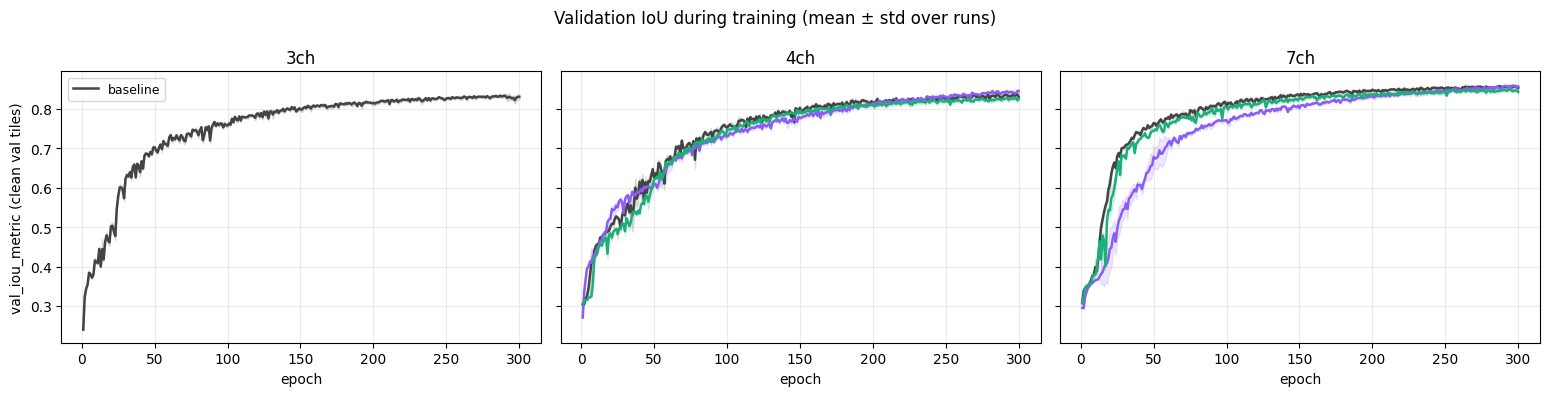

In [4]:
if not os.path.exists(CSV_PATH):
    print("No CSV yet — run the export cell first."); hist = None
else:
    hist = pd.read_csv(CSV_PATH)
    STYLE = {"v2_yaw_correction-epsV1": ("#444444", "baseline"),
             "v7_groupnorm": ("#8b5cf6", "groupnorm"),
             "v7_photoaug": ("#1baf7a", "photoaug")}
    variants = sorted(hist.channels.unique())
    fig, axes = plt.subplots(1, len(variants), figsize=(5.2 * len(variants), 4.0), sharey=True)
    for ax, ch in zip(np.atleast_1d(axes), variants):
        sub = hist[hist.channels == ch]
        for exp in EXPERIMENTS:
            g = sub[sub.experiment == exp]
            if not len(g):
                continue
            color, label = STYLE.get(exp, (None, exp))
            m = g.groupby("epoch")["val_iou_metric"].agg(["mean", "std"])
            ax.plot(m.index, m["mean"], color=color, lw=1.8, label=label)
            ax.fill_between(m.index, m["mean"] - m["std"], m["mean"] + m["std"],
                            color=color, alpha=0.15)
        ax.set_title(f"{ch}ch"); ax.set_xlabel("epoch"); ax.grid(alpha=0.25)
    np.atleast_1d(axes)[0].set_ylabel("val_iou_metric (clean val tiles)")
    np.atleast_1d(axes)[0].legend(fontsize=9)
    plt.suptitle("Validation IoU during training (mean ± std over runs)")
    plt.tight_layout(); plt.show()

## 4. Train vs. validation loss per experiment (7ch)

Shape check: noisy tail = the constant-LR wobble Candidate 3 targets; a widening
train/val split = overfitting; photoaug's train loss is on jittered inputs
(higher level is expected).

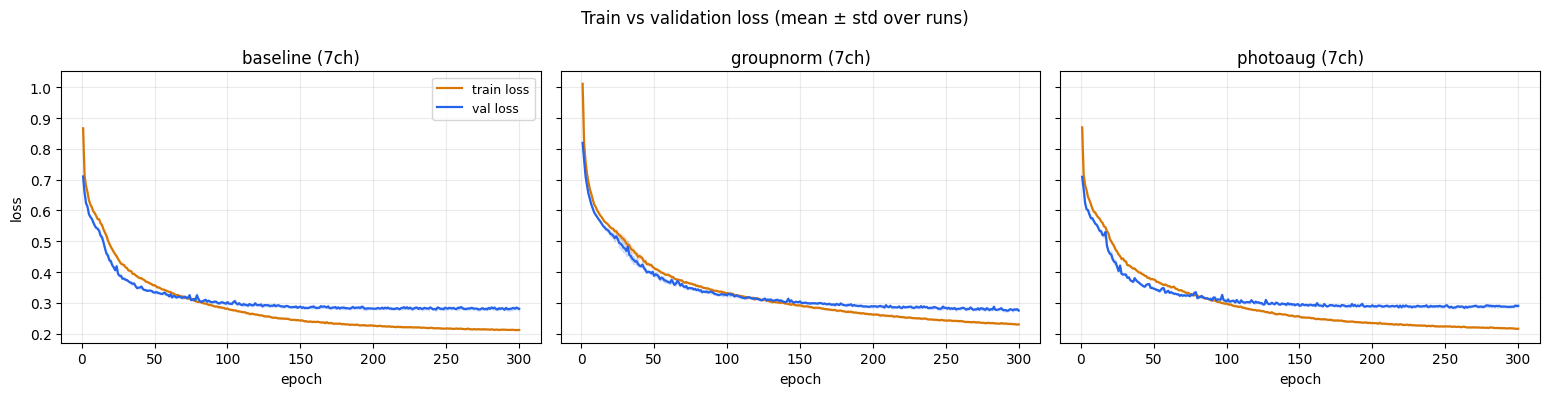

In [5]:
if hist is not None:
    exps = [e for e in EXPERIMENTS if (hist.experiment == e).any()]
    fig, axes = plt.subplots(1, len(exps), figsize=(5.2 * len(exps), 4.0), sharey=True)
    for ax, exp in zip(np.atleast_1d(axes), exps):
        g = hist[(hist.experiment == exp) & (hist.channels == 7)]
        for col, color, label in (("loss", "#d97706", "train loss"),
                                  ("val_loss", "#2563eb", "val loss")):
            m = g.groupby("epoch")[col].agg(["mean", "std"])
            ax.plot(m.index, m["mean"], color=color, lw=1.6, label=label)
            ax.fill_between(m.index, m["mean"] - m["std"], m["mean"] + m["std"],
                            color=color, alpha=0.15)
        ax.set_title(f"{STYLE.get(exp, (None, exp))[1]} (7ch)")
        ax.set_xlabel("epoch"); ax.grid(alpha=0.25)
    np.atleast_1d(axes)[0].set_ylabel("loss"); np.atleast_1d(axes)[0].legend(fontsize=9)
    plt.suptitle("Train vs validation loss (mean ± std over runs)")
    plt.tight_layout(); plt.show()

## 5. Convergence diagnostics — the Candidate-3 question in numbers

Per (experiment, variant), mean over runs:
- **tail slope**: linear fit of `val_iou_metric` over the last 50 epochs, in
  IoU per 100 epochs — clearly positive means training was still climbing;
- **best epoch**: where val IoU peaked;
- **final − best gap**: how far the epoch-300 checkpoint sits below the run's
  own best-val epoch (by this internal val metric).

In [6]:
if hist is not None:
    rows = []
    for (exp, ch, run), g in hist.groupby(["experiment", "channels", "run_number"]):
        g = g.sort_values("epoch")
        tail = g[g.epoch > g.epoch.max() - 50]
        slope = np.polyfit(tail.epoch, tail.val_iou_metric, 1)[0] * 100
        best_i = g.val_iou_metric.idxmax()
        rows.append({"experiment": exp, "channels": ch, "run": run,
                     "tail_slope_per100ep": slope,
                     "best_epoch": int(g.loc[best_i, "epoch"]),
                     "final_minus_best": g.val_iou_metric.iloc[-1] - g.loc[best_i, "val_iou_metric"]})
    diag = pd.DataFrame(rows)
    summary = (diag.groupby(["experiment", "channels"])
               [["tail_slope_per100ep", "best_epoch", "final_minus_best"]]
               .mean().round(4))
    pd.set_option("display.width", 160)
    display(summary)
    print("\nReading: tail_slope clearly > 0 -> still climbing at 300 epochs;")
    print("final_minus_best clearly < 0 -> final-epoch selection leaves val-IoU on the table.")

tail_slope_per100ep  best_epoch  final_minus_best
experiment              channels                                                   
v2_yaw_correction-epsV1 3                      0.0040       286.0           -0.0061
                        4                      0.0142       289.6           -0.0097
                        7                      0.0071       282.4           -0.0077
v7_groupnorm            4                      0.0259       288.2           -0.0037
                        7                      0.0198       294.0           -0.0037
v7_photoaug             4                      0.0141       290.0           -0.0051
                        7                      0.0056       284.8           -0.0086


Reading: tail_slope clearly > 0 -> still climbing at 300 epochs;
final_minus_best clearly < 0 -> final-epoch selection leaves val-IoU on the table.
